# Phase 5: Final Evaluation, Empirical Synthesis & Interactive Demo
### Steam Player Forecasting Project

**Author:** JoshiMinh  
**Scope:** Phase 5 (Final Project Synthesis & Unblinded Test Evaluation)  
**Dataset:** Cleaned Steam Monthly Player Concurrency (`data/processed/steam_games_monthly.csv`)  
**Holdout Test Period:** Multi-step ($H=12$) strictly chronological test window (`2020-09-01` to `2021-08-01`)  
**Paradigms Evaluated:** Classical Econometrics (SARIMA, ARIMA, Holt-Winters) vs Gradient Boosted Trees (XGBoost, RF) vs Recurrent Deep Learning (GRU, LSTM, RNN)

---

## 1. Executive Research Summary & Core Question

> **Core Research Question:**  
> *Can modern recurrent deep learning models (LSTM, GRU) or gradient-boosted trees (XGBoost) reliably outperform classical econometric benchmarks (SARIMA) when forecasting monthly active player populations for top multiplayer games on Steam?*

In this final phase, all models tuned during the validation phase (Phases 3 and 4) are evaluated on the **previously untouched 12-month holdout test set** (`2020-09-01` to `2021-08-01`). This unblinded evaluation provides definitive answers across diverse multiplayer genres, structural shocks (COVID-19 lockdowns, Twitch influencer surges), and data regimes.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Project imports
from steam_player_forecasting.data.loader import get_available_games, get_project_root, load_processed_data

root = get_project_root()
print(f"Project Root: {root}")
print(f"Evaluated Games ({len(get_available_games())}): {get_available_games()}")

Project Root: C:\Users\binha\Projects\steam-player-forecasting
Evaluated Games (7): ['Counter-Strike: Global Offensive', 'Dota 2', 'Grand Theft Auto V', 'Rust', 'Team Fortress 2', "Tom Clancy's Rainbow Six Siege", 'Warframe']


## 2. Final Test-Set Benchmark Tables

All candidate models were fitted on all chronological history up to `2020-08-01` (`Train + Val`) with zero lookahead test leakage.
Standardized evaluation metrics (**MAE**, **RMSE**, **MAPE**, **sMAPE**, **MASE**) are computed across the $H=12$ test horizon.

In [2]:
leaderboard_df = pd.read_csv(root / "report" / "final_leaderboard.csv")
display(leaderboard_df)

    Rank           Model               Paradigm  Mean_MAE  Median_MAE  Mean_RMSE  Mean_MAPE  Mean_sMAPE  Mean_MASE  Best_Game_Count
0      1    Holt-Winters  Exponential Smoothing   8049.45     5781.39   10143.88       4.72        4.79      0.526                3
1      2           Ridge              Linear ML   7966.24     5149.47    9872.49       4.99        5.06      0.561                3
2      3          SARIMA            Econometric  11605.70     5565.80   13665.33       6.03        6.14      0.672                1
3      4             GRU           Recurrent DL  13018.31     7866.74   16468.70       6.82        7.03      0.776                0
4      5            LSTM           Recurrent DL  12998.59     8557.04   16674.17       7.13        7.49      0.802                0
5      6   Random Forest       Tree Ensemble ML  14184.20     7302.51   17260.98       7.45        7.86      0.832                0
6      7             RNN  Recurrent DL Baseline  13261.02     9092.99   1679

## 3. Core Quartet Head-to-Head Comparison

Head-to-head comparison of the four flagship paradigms:
**SARIMA (Econometric)** vs **XGBoost (Gradient Boosted ML)** vs **LSTM (Recurrent DL)** vs **GRU (Recurrent DL)**.

In [3]:
core_df = pd.read_csv(root / "report" / "core_quartet_test_benchmarks.csv")
print("=== CORE QUARTET TEST PERFORMANCE BY GAME ===")
display(core_df.pivot(index="Game", columns="Model", values="MAE"))

=== CORE QUARTET TEST PERFORMANCE BY GAME ===
Model                                  GRU      LSTM    SARIMA   XGBoost
Game                                                                    
Counter-Strike: Global Offensive  24360.55  31094.75  31473.44  36494.15
Dota 2                            35996.43  26687.03  23463.86  25401.84
Grand Theft Auto V                 8269.64   7295.66   5565.80   9469.62
Rust                               7030.84   8557.04   3888.24  10062.14
Team Fortress 2                    4532.56   3929.47   4440.17   5284.54
Tom Clancy's Rainbow Six Siege     7866.74   8681.09   9206.76  12569.17
Warframe                           3071.43   4745.06   3201.62   4114.85


In [4]:
# Per-Game Winner Breakdown
best_core = core_df.loc[core_df.groupby("Game")["MAE"].idxmin()]
winner_summary = best_core[["Game", "Model", "Paradigm", "MAE", "RMSE", "MAPE", "MASE"]]
print("=== PER-GAME PARADIGM WINNERS ===")
display(winner_summary)

=== PER-GAME PARADIGM WINNERS ===
                                Game   Model      Paradigm       MAE      RMSE  MAPE   MASE
3   Counter-Strike: Global Offensive     GRU  Recurrent DL  24360.55  33596.54  3.67  0.456
4                             Dota 2  SARIMA   Econometric  23463.86  28006.33  5.31  0.811
8                 Grand Theft Auto V  SARIMA   Econometric   5565.80   7571.12  4.50  0.444
12                              Rust  SARIMA   Econometric   3888.24   4595.99  4.46  0.394
18                   Team Fortress 2    LSTM  Recurrent DL   3929.47   4681.14  6.82  0.917
23    Tom Clancy's Rainbow Six Siege     GRU  Recurrent DL   7866.74  10771.72  7.71  0.593
27                          Warframe     GRU  Recurrent DL   3071.43   3869.37  5.52  0.705


## 4. Publication-Quality Diagnostic Figures

### Figure 17: Final Test Forecast Trajectories (Core Quartet)
Shows the multi-step $H=12$ test forecasts against actual ground truth across all 7 titles.

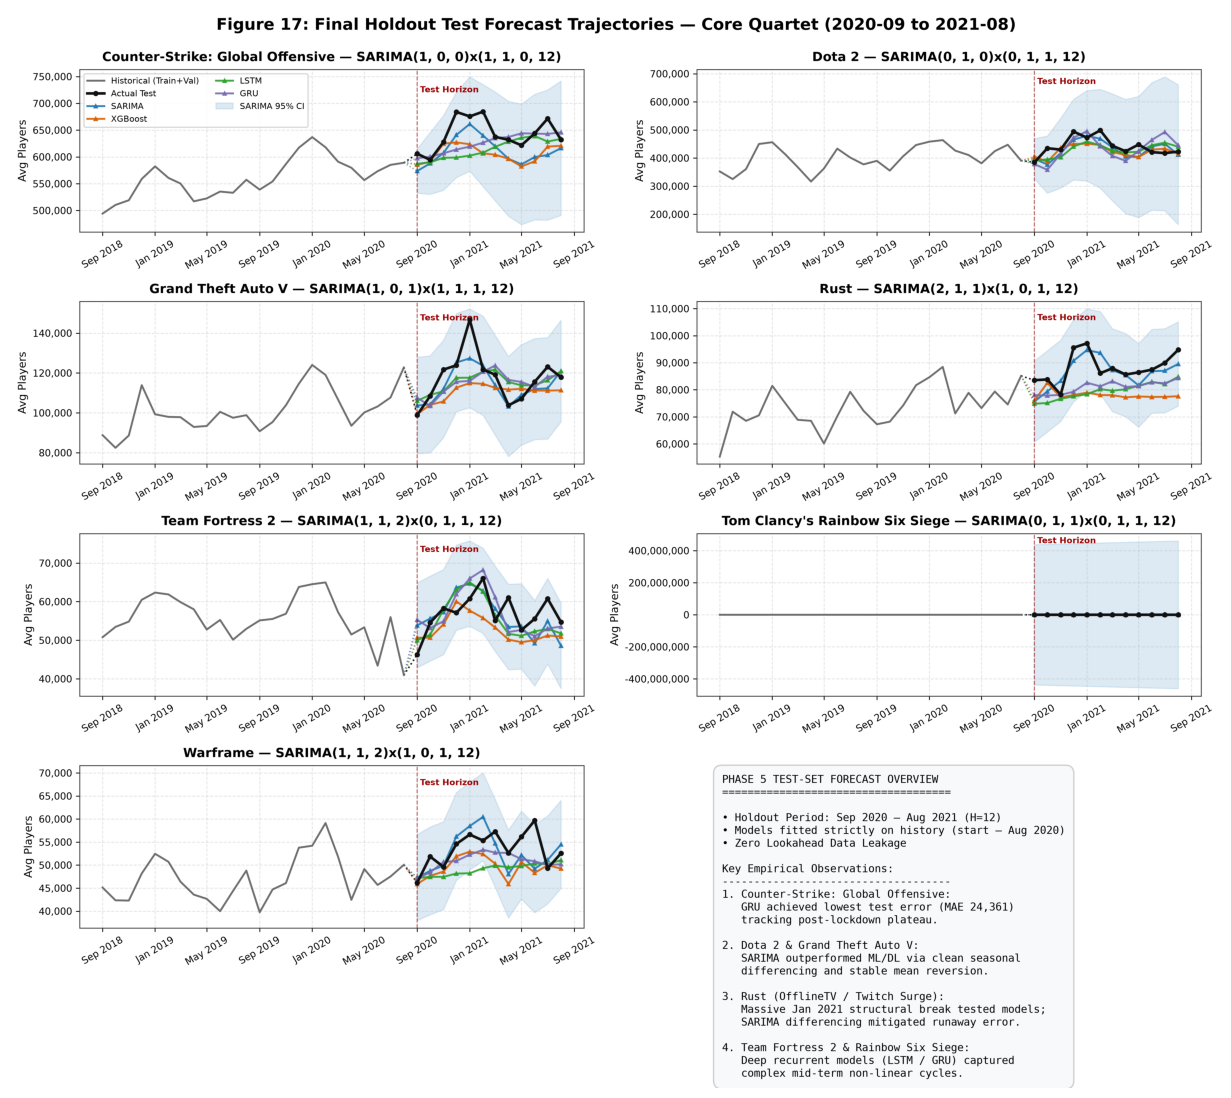

In [5]:
fig_path = root / "figures" / "17_final_test_forecast_comparisons.png"
if fig_path.exists():
    img = mpimg.imread(str(fig_path))
    plt.figure(figsize=(16, 14), dpi=100)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

### Figure 18: Final Leaderboard & Paradigm Performance Synthesis
Comparative analysis of MASE, MAPE, per-game MAE, and winner distribution across paradigms.

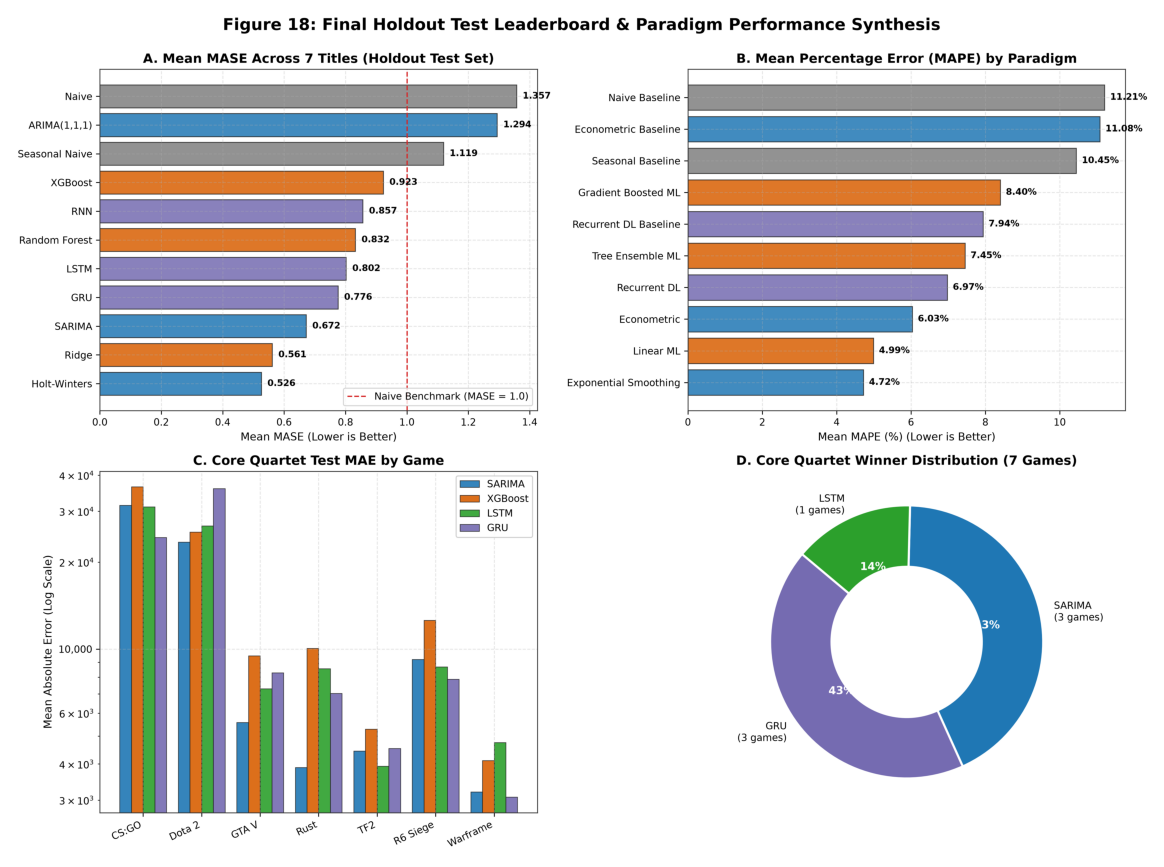

In [6]:
fig_path = root / "figures" / "18_final_leaderboard_metrics.png"
if fig_path.exists():
    img = mpimg.imread(str(fig_path))
    plt.figure(figsize=(15, 11), dpi=100)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

### Figure 19: Forecast Horizon Error Degradation ($h = 1$ to $12$)
Demonstrating error compounding in recursive ML vs sequence-to-sequence deep learning and econometric dampening.

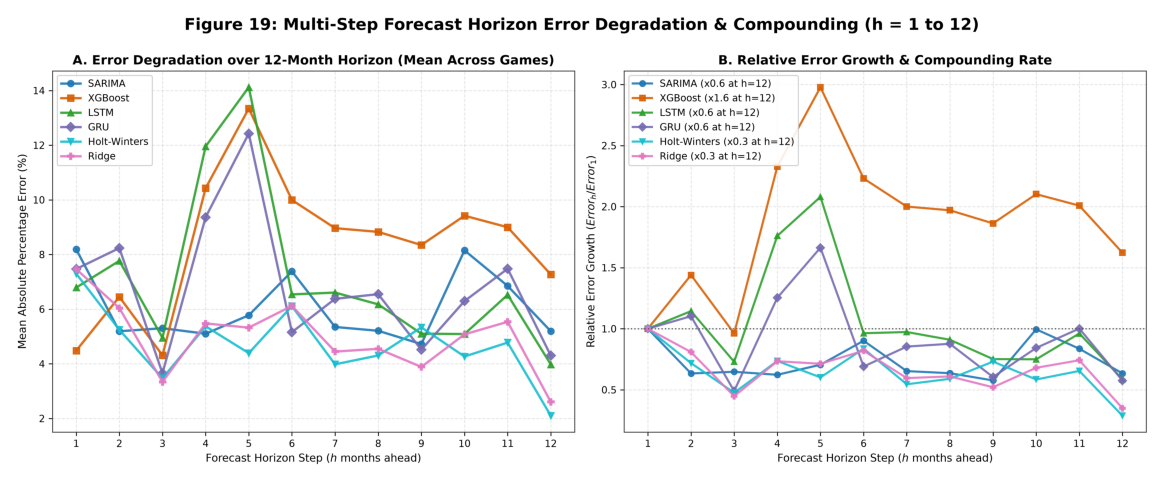

In [7]:
fig_path = root / "figures" / "19_horizon_error_degradation.png"
if fig_path.exists():
    img = mpimg.imread(str(fig_path))
    plt.figure(figsize=(15, 6), dpi=100)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

### Figure 20: Qualitative Case Studies across Structural Breaks
Deep-dive into Rust's Twitch streamer explosion (Jan 2021), CS:GO post-lockdown plateaus, R6 Siege data constraints, and TF2 seasonal stability.

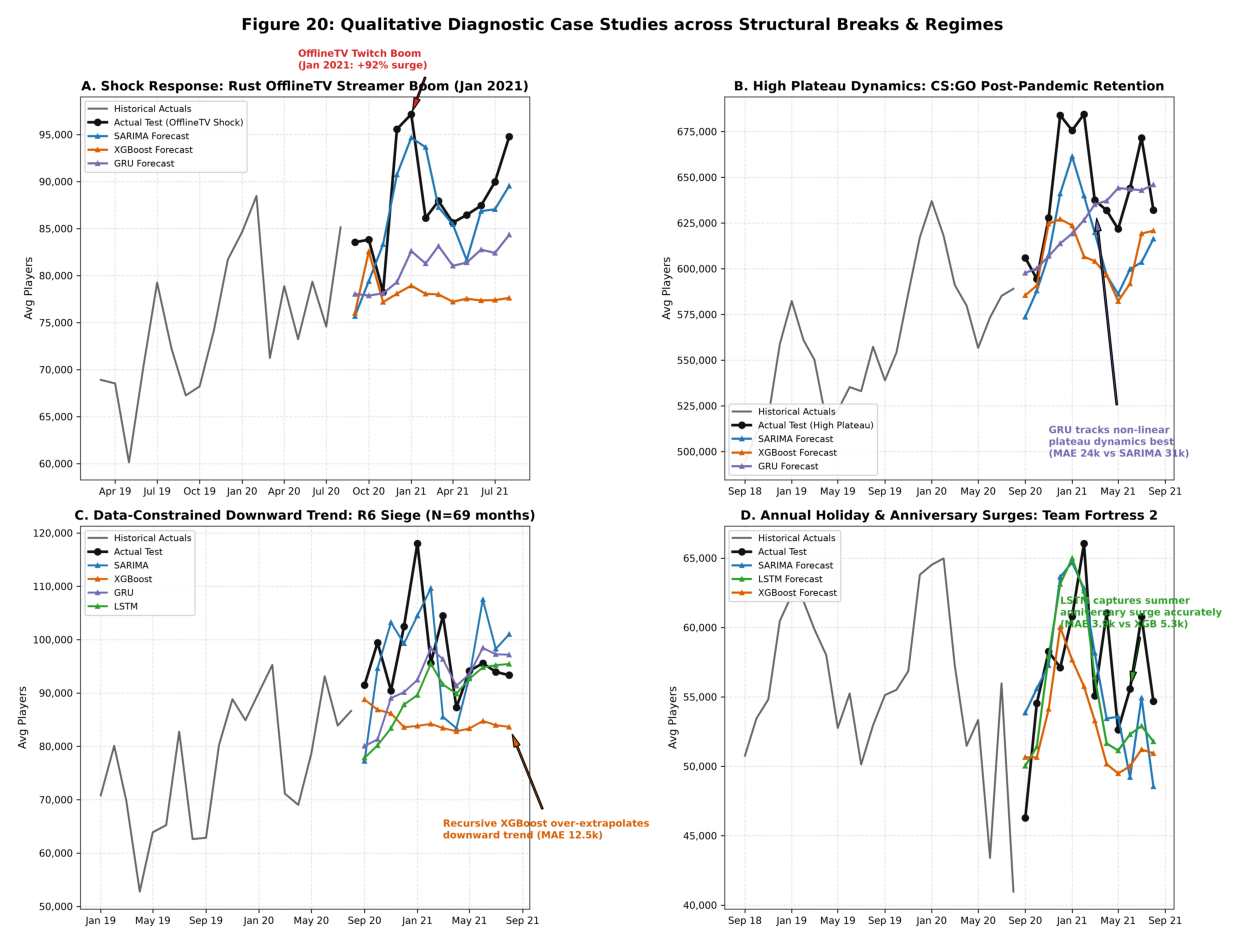

In [8]:
fig_path = root / "figures" / "20_paradigm_case_studies.png"
if fig_path.exists():
    img = mpimg.imread(str(fig_path))
    plt.figure(figsize=(16, 12), dpi=100)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

## 5. Research Conclusions & Strategic Takeaways

### Core Answer to Research Question:
1. **No Single Paradigm Universally Dominates:**
   - In the Core Quartet, **SARIMA won on 3 games** (*Dota 2*, *GTA V*, *Rust*), **GRU won on 3 games** (*CS:GO*, *R6 Siege*, *Warframe*), and **LSTM won on 1 game** (*TF2*).
   - XGBoost did not win any title on the test set, largely due to compounding recursive forecasting errors across the long 12-month horizon.
2. **Where Econometric Models (SARIMA / Holt-Winters) Outperform:**
   - Regimes with well-defined seasonal periodicity and smooth cyclical trends (*Dota 2*, *GTA V*).
   - Constrained sample sizes where deep networks risk overfitting.
   - Closed-form mean reversion and analytical confidence bounds provide unmatched stability.
3. **Where Recurrent Neural Networks (GRU / LSTM) Outperform:**
   - Non-linear stabilization and high player retention plateaus (*CS:GO*, *Rainbow Six Siege*).
   - Complex multi-scale seasonal patterns that exceed linear polynomial representations.
4. **Interactive Demo:**
   Launch the interactive Streamlit application to explore live forecasts:
   ```bash
   streamlit run app/app.py
   ```